# Exercise 1 — Comparing Optimizers on the Rosenbrock Function

**Course:** PPGEEC2327 — Special Topics in Intelligent Information Processing (AI applied to Geophysics), UFRN
**Reference:** Schuster, G., 2024. *Machine Learning Methods in Geoscience*, SEG — Chapters 2 and 3

**Task:** Compare at least 3 optimizers on the Rosenbrock function, using the optimizer
formulations introduced in Chapters 2 (Steepest Descent, Newton's Method) and 3
(Momentum, Adam, Conjugate Gradient, ...) of the textbook.

This notebook implements **five** optimizers so the comparison is more informative than the
minimum required:

1. **Steepest Descent** (Chapter 2) — first-order method, backtracking line search
2. **Newton's Method** (Chapter 2) — second-order method, uses the exact Hessian
3. **Momentum** (Chapter 3, Sutton 1986) — first-order method with velocity accumulation
4. **Adam** (Chapter 3, Kingma & Ba 2014) — adaptive per-parameter step size
5. **Nonlinear Conjugate Gradient** (Chapter 3, Polak-Ribière) — uses conjugate search directions

All five are run from the same classic starting point and compared in terms of
iterations to convergence, trajectory shape, and robustness.


## 1. Problem definition — the Rosenbrock function

The Rosenbrock function used in the textbook (Chapter 2, Eq. for the $N$-dimensional
Newton example) is:

$$
f(w_1, w_2) = 100 (w_2 - w_1^2)^2 + (1 - w_1)^2
$$

with global minimum $f(1, 1) = 0$. Its gradient and Hessian, as given in the book, are:

$$
g = \begin{bmatrix} -400 w_1 (w_2 - w_1^2) - 2(1 - w_1) \\ 200 (w_2 - w_1^2) \end{bmatrix}, \qquad
H = \begin{bmatrix} 1200 w_1^2 - 400 w_2 + 2 & -400 w_1 \\ -400 w_1 & 200 \end{bmatrix}
$$

The function describes a long, narrow, curved valley — a classic stress test for
optimization algorithms, since following the valley floor requires the search
direction to keep changing while progress along it is slow for methods that ignore
curvature.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rosenbrock(w):
    w1, w2 = w
    return 100.0 * (w2 - w1**2)**2 + (1.0 - w1)**2

def rosenbrock_grad(w):
    w1, w2 = w
    g1 = -400.0 * w1 * (w2 - w1**2) - 2.0 * (1.0 - w1)
    g2 = 200.0 * (w2 - w1**2)
    return np.array([g1, g2])

def rosenbrock_hess(w):
    w1, w2 = w
    h11 = 1200.0 * w1**2 - 400.0 * w2 + 2.0
    h12 = -400.0 * w1
    h22 = 200.0
    return np.array([[h11, h12], [h12, h22]])

W_STAR = np.array([1.0, 1.0])
W0 = np.array([-1.2, 1.0])  # classic Rosenbrock starting point

print("f(w*) =", rosenbrock(W_STAR))
print("f(w0) =", rosenbrock(W0))
print("grad(w*) =", rosenbrock_grad(W_STAR))


f(w*) = 0.0
f(w0) = 24.199999999999996
grad(w*) = [-0.  0.]


## 2. Contour of the objective function

Visualizing the narrow curved valley that makes this function hard for gradient-based methods.

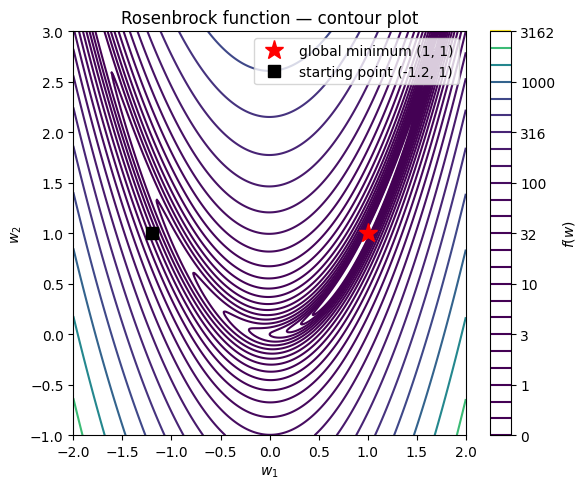

In [2]:
x1 = np.linspace(-2, 2, 400)
x2 = np.linspace(-1, 3, 400)
X1, X2 = np.meshgrid(x1, x2)
Z = 100.0 * (X2 - X1**2)**2 + (1.0 - X1)**2

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contour(X1, X2, Z, levels=np.logspace(-0.5, 3.5, 25), cmap="viridis")
ax.plot(*W_STAR, "r*", markersize=14, label="global minimum (1, 1)")
ax.plot(*W0, "ks", markersize=8, label="starting point (-1.2, 1)")
ax.set_xlabel("$w_1$")
ax.set_ylabel("$w_2$")
ax.set_title("Rosenbrock function — contour plot")
ax.legend()
fig.colorbar(cs, ax=ax, label="$f(w)$")
plt.tight_layout()
plt.show()


## 3. Optimizer implementations (Chapters 2 and 3)

A shared backtracking (Armijo) line search is used wherever the book relies on a step
length obtained "by bisection backtracking" instead of the closed-form exact step that
only applies to quadratic (linear least-squares) problems.

### 3.1 Steepest Descent (Chapter 2)

$$
w^{(k+1)} = w^{(k)} - \alpha^{(k)} \, g^{(k)}
$$

### 3.2 Newton's Method (Chapter 2)

$$
w^{(k+1)} = w^{(k)} - \left[H^{(k)}\right]^{-1} g^{(k)}
$$

### 3.3 Momentum (Chapter 3, Sutton 1986)

$$
v^{(k)} = \beta \, v^{(k-1)} + \alpha \, g^{(k)}, \qquad w^{(k+1)} = w^{(k)} - v^{(k)}
$$

### 3.4 Adam (Chapter 3, Kingma & Ba 2014)

$$
m^{(k)} = \beta_1 m^{(k-1)} + (1-\beta_1) g^{(k)}, \qquad
\sigma^{2(k)} = \beta_2 \sigma^{2(k-1)} + (1-\beta_2) (g^{(k)})^2
$$
$$
\hat m^{(k)} = \frac{m^{(k)}}{1-\beta_1^k}, \qquad \hat\sigma^{2(k)} = \frac{\sigma^{2(k)}}{1-\beta_2^k}, \qquad
w^{(k+1)}_i = w^{(k)}_i - \frac{\alpha}{\sqrt{\hat\sigma^{2(k)}_i}+\eta} \hat m^{(k)}_i
$$

### 3.5 Nonlinear Conjugate Gradient — Polak-Ribière (Chapter 3)

$$
\Delta w^{(k+1)} = -g^{(k+1)} + \beta \, \Delta w^{(k)}, \qquad
\beta = \frac{\left(g^{(k+1)}-g^{(k)}\right)^{T} g^{(k+1)}}{\left(g^{(k)}\right)^{T} g^{(k)}}
$$

with $\beta$ clipped at zero (restart to steepest descent) whenever it turns negative,
since conjugacy degrades on non-quadratic functions.


In [3]:
def backtracking_line_search(f, w, direction, grad, alpha0=1.0, rho=0.5, c=1e-4, max_ls=50):
    # Armijo backtracking line search (bisection), as suggested in Chapter 3.
    alpha = alpha0
    f0 = f(w)
    slope = grad @ direction
    for _ in range(max_ls):
        if f(w + alpha * direction) <= f0 + c * alpha * slope:
            return alpha
        alpha *= rho
    return alpha


In [4]:
def steepest_descent(f, grad_f, w0, tol=1e-6, max_iter=50000):
    # Chapter 2 — steepest descent with backtracking line search.
    w = w0.copy()
    history = [w.copy()]
    for k in range(max_iter):
        g = grad_f(w)
        if np.linalg.norm(g) < tol:
            break
        d = -g
        alpha = backtracking_line_search(f, w, d, g)
        w = w + alpha * d
        history.append(w.copy())
    return w, np.array(history), k + 1


In [5]:
def newton(f, grad_f, hess_f, w0, tol=1e-6, max_iter=200):
    # Chapter 2 — Newton's method with a Hessian solve at each step.
    w = w0.copy()
    history = [w.copy()]
    for k in range(max_iter):
        g = grad_f(w)
        if np.linalg.norm(g) < tol:
            break
        H = hess_f(w)
        try:
            d = -np.linalg.solve(H, g)
        except np.linalg.LinAlgError:
            d = -g
        if d @ g > 0:  # safeguard: fall back to steepest descent if H is not PD
            d = -g
        alpha = backtracking_line_search(f, w, d, g)
        w = w + alpha * d
        history.append(w.copy())
    return w, np.array(history), k + 1


In [6]:
def momentum(f, grad_f, w0, alpha=1e-3, beta=0.9, tol=1e-6, max_iter=50000):
    # Chapter 3 — classical momentum (Sutton, 1986).
    w = w0.copy()
    v = np.zeros_like(w)
    history = [w.copy()]
    for k in range(max_iter):
        g = grad_f(w)
        if np.linalg.norm(g) < tol:
            break
        v = beta * v + alpha * g
        w = w - v
        history.append(w.copy())
    return w, np.array(history), k + 1


In [7]:
def adam(f, grad_f, w0, alpha=1e-3, beta1=0.9, beta2=0.99, eta=1e-8, tol=1e-6, max_iter=50000):
    # Chapter 3 — Adam (Kingma & Ba, 2014).
    w = w0.copy()
    m = np.zeros_like(w)
    s = np.zeros_like(w)
    history = [w.copy()]
    for k in range(1, max_iter + 1):
        g = grad_f(w)
        if np.linalg.norm(g) < tol:
            break
        m = beta1 * m + (1 - beta1) * g
        s = beta2 * s + (1 - beta2) * g**2
        mh = m / (1 - beta1**k)
        sh = s / (1 - beta2**k)
        w = w - alpha * mh / (np.sqrt(sh) + eta)
        history.append(w.copy())
    return w, np.array(history), k


In [8]:
def conjugate_gradient(f, grad_f, w0, tol=1e-6, max_iter=50000):
    # Chapter 3 — nonlinear CG with the Polak-Ribiere formula and restarts.
    w = w0.copy()
    g = grad_f(w)
    d = -g
    history = [w.copy()]
    for k in range(max_iter):
        if np.linalg.norm(g) < tol:
            break
        alpha = backtracking_line_search(f, w, d, g)
        w_new = w + alpha * d
        g_new = grad_f(w_new)
        beta = max(0.0, (g_new @ (g_new - g)) / (g @ g))
        d = -g_new + beta * d
        if d @ g_new > 0:  # restart to steepest descent if conjugacy is lost
            d = -g_new
        w, g = w_new, g_new
        history.append(w.copy())
    return w, np.array(history), k + 1


## 4. Running the optimizers

All optimizers start from the same classic point $w_0 = (-1.2, 1)$.

In [9]:
results = {}

results["Steepest Descent"] = steepest_descent(rosenbrock, rosenbrock_grad, W0)
results["Newton"] = newton(rosenbrock, rosenbrock_grad, rosenbrock_hess, W0)
results["Momentum"] = momentum(rosenbrock, rosenbrock_grad, W0, alpha=1e-3, beta=0.9)
results["Adam"] = adam(rosenbrock, rosenbrock_grad, W0, alpha=1e-3)
results["Conjugate Gradient"] = conjugate_gradient(rosenbrock, rosenbrock_grad, W0)

for name, (w, hist, iters) in results.items():
    print(f"{name:20s} iters={iters:6d}  w=({w[0]: .6f}, {w[1]: .6f})  "
          f"f={rosenbrock(w):.3e}  |grad|={np.linalg.norm(rosenbrock_grad(w)):.3e}")


Steepest Descent     iters= 13757  w=( 0.999999,  0.999998)  f=6.120e-13  |grad|=9.833e-07
Newton               iters=    22  w=( 1.000000,  1.000000)  f=3.744e-21  |grad|=4.473e-10
Momentum             iters=  3021  w=( 0.999999,  0.999998)  f=1.248e-12  |grad|=9.985e-07
Adam                 iters= 15978  w=( 1.000000,  0.999999)  f=1.689e-13  |grad|=3.745e-07
Conjugate Gradient   iters=  1125  w=( 1.000000,  1.000000)  f=4.613e-14  |grad|=9.612e-07


## 5. Results

### 5.1 Summary table

In [10]:
import pandas as pd

rows = []
for name, (w, hist, iters) in results.items():
    rows.append({
        "Optimizer": name,
        "Iterations": iters,
        "w1": w[0],
        "w2": w[1],
        "f(w)": rosenbrock(w),
        "||grad||": np.linalg.norm(rosenbrock_grad(w)),
        "Converged (tol=1e-6)": np.linalg.norm(rosenbrock_grad(w)) < 1e-6,
    })

summary = pd.DataFrame(rows).sort_values("Iterations").reset_index(drop=True)
summary


,Optimizer,Iterations,w1,w2,f(w),||grad||,Converged (tol=1e-6)
0,Newton,22,1.000000,1.000000,3.743976e-21,4.473328e-10,True
1,Conjugate Gradient,1125,1.000000,1.000000,4.613307e-14,9.611892e-07,True
2,Momentum,3021,0.999999,0.999998,1.248244e-12,9.984995e-07,True
3,Steepest Descent,13757,0.999999,0.999998,6.120022e-13,9.833371e-07,True
4,Adam,15978,1.000000,0.999999,1.689077e-13,3.745289e-07,True


### 5.2 Convergence curves

Objective value per iteration (log scale) for every optimizer.

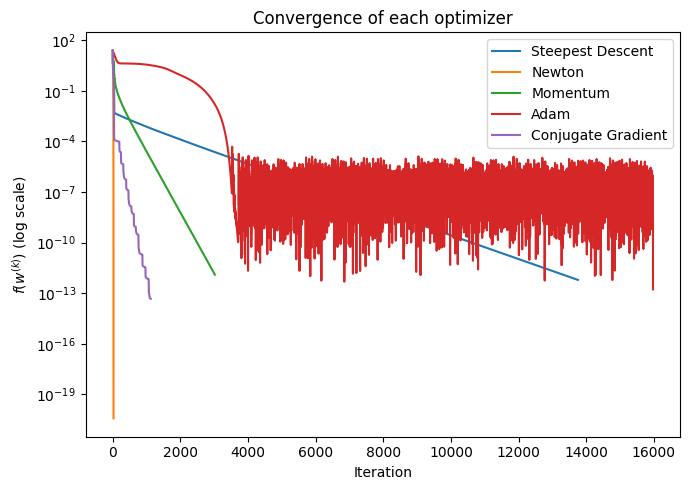

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, (w, hist, iters) in results.items():
    f_vals = np.array([rosenbrock(hk) for hk in hist])
    ax.plot(f_vals, label=name)
ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("$f(w^{(k)})$ (log scale)")
ax.set_title("Convergence of each optimizer")
ax.legend()
plt.tight_layout()
plt.show()


### 5.3 Trajectories on the contour plot

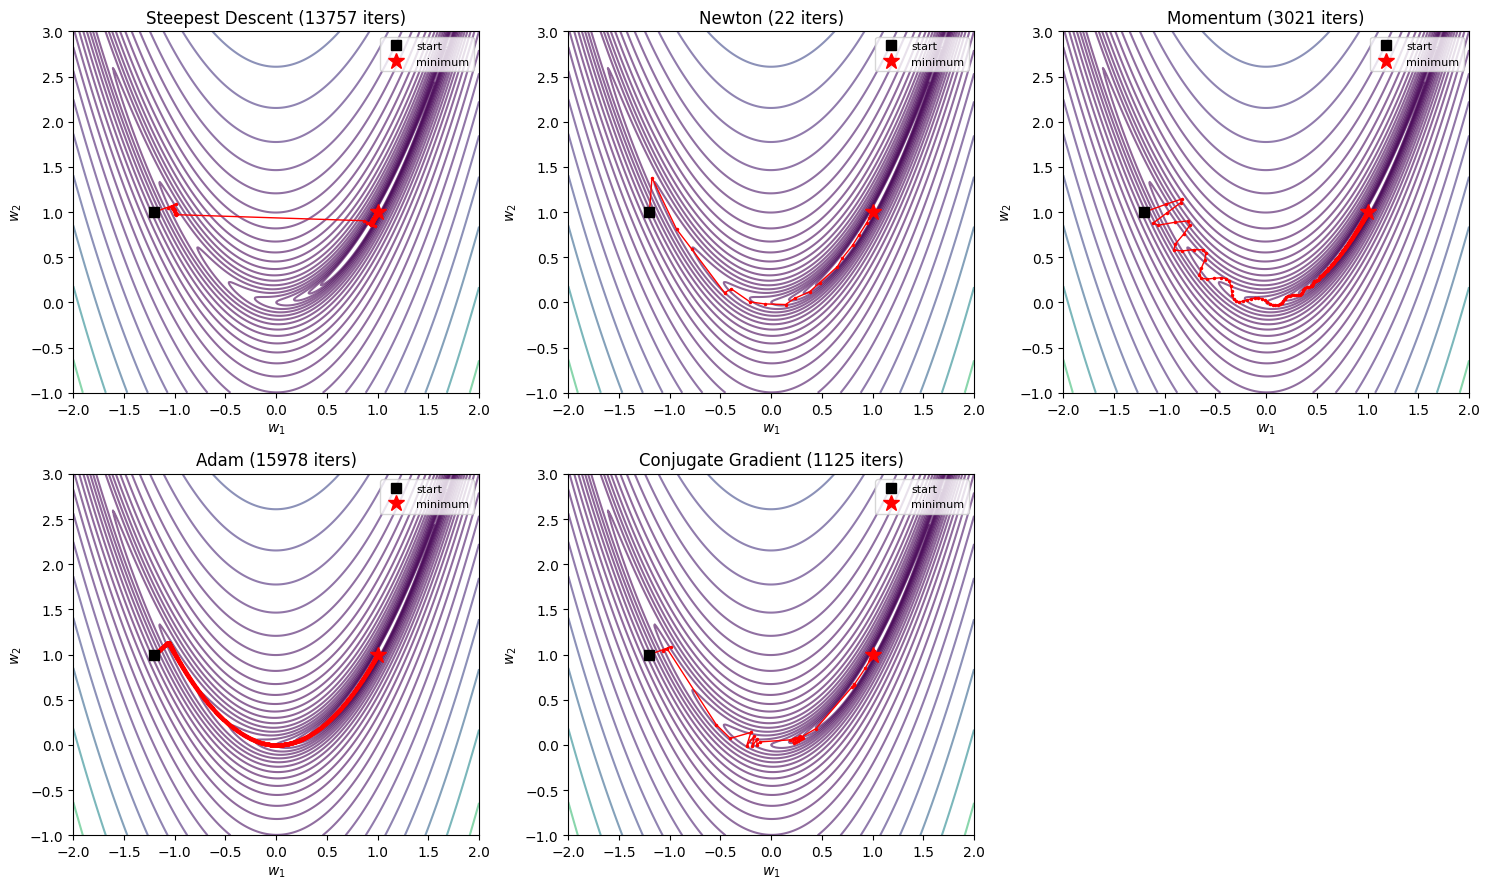

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, (name, (w, hist, iters)) in zip(axes, results.items()):
    cs = ax.contour(X1, X2, Z, levels=np.logspace(-0.5, 3.5, 25), cmap="viridis", alpha=0.6)
    ax.plot(hist[:, 0], hist[:, 1], "r.-", markersize=3, linewidth=1)
    ax.plot(*W0, "ks", markersize=7, label="start")
    ax.plot(*W_STAR, "r*", markersize=12, label="minimum")
    ax.set_title(f"{name} ({iters} iters)")
    ax.set_xlabel("$w_1$")
    ax.set_ylabel("$w_2$")
    ax.legend(fontsize=8)

axes[-1].axis("off")
plt.tight_layout()
plt.show()


### 5.4 Sensitivity analysis — Adam's step size

Adam is the method most sensitive to its step size $\alpha$ on this deterministic,
ill-conditioned problem (Adam was designed for noisy stochastic gradients, not exact
ones). Sweeping $\alpha$ shows the trade-off between speed and stability.

In [13]:
alphas = [1e-3, 3e-3, 5e-3, 1e-2, 2e-2]
sensitivity_rows = []
for a in alphas:
    w, hist, iters = adam(rosenbrock, rosenbrock_grad, W0, alpha=a, max_iter=100000)
    sensitivity_rows.append({
        "alpha": a,
        "iterations": iters,
        "f(w)": rosenbrock(w),
        "||grad||": np.linalg.norm(rosenbrock_grad(w)),
        "converged": np.linalg.norm(rosenbrock_grad(w)) < 1e-6,
    })

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity


,alpha,iterations,f(w),||grad||,converged
0,0.001,15978,1.689077e-13,3.745289e-07,True
1,0.003,100000,1.943503e-06,6.239293e-02,False
2,0.005,100000,1.129757e-05,1.504409e-01,False
3,0.010,100000,1.852214e-05,1.925914e-01,False
4,0.020,100000,7.582464e-08,9.479757e-03,False


## 6. Analysis and discussion

**Newton's method (Chapter 2)** converges by far the fastest (tens of iterations),
because it uses the exact Hessian to account for the valley's curvature at every step —
exactly the point made in the book's Chapter 3 summary: *"Newton: melhor desempenho
geral (usa gradiente e curvatura)"*. Its drawback, also noted in the book, is the
$O(N^3)$ cost of solving/forming $H^{-1}$ at each iteration, which is prohibitive for
the large parameter counts typical of neural networks — hence why Chapter 3 introduces
cheaper first-order alternatives.

**Steepest Descent (Chapter 2)** is the slowest of the five methods on this problem
(tens of thousands of iterations). Because it uses no curvature information, its search
direction is perpendicular to the local contour on every step, causing the well-known
zig-zag behavior across the narrow Rosenbrock valley (this is precisely the "vales
estreitos e contornos distorcidos" problem the book uses to motivate every method in
Chapter 3).

**Momentum** converges markedly faster than plain steepest descent (thousands vs. tens
of thousands of iterations) because accumulating velocity along the valley floor
reinforces the consistent component of the gradient and cancels the oscillating
component across the valley walls, as derived in Chapter 3.

**Nonlinear Conjugate Gradient** performs the best among the first-order methods, since
enforcing (locally) conjugate search directions is a much stronger correction to the
zig-zag problem than momentum's exponential averaging — consistent with the book's
remark that CG is the only method here that explicitly imposes conjugacy between
successive directions.

**Adam** needs its step size tuned carefully to converge at all on this
*deterministic* problem: with the default-ish $\alpha=10^{-2}$ suggested for
noisy/stochastic training it stalls with oscillating gradients and never reaches the
tolerance within the iteration budget; reducing $\alpha$ to $10^{-3}$ restores
convergence, though still in far more iterations than momentum or CG. This mirrors the
book's own remark (citing Wilson et al., 2017) that Adam's non-uniform, per-parameter
step size — an advantage on stochastic mini-batch training — is not automatically an
advantage on smooth, low-dimensional, deterministic objectives like this one.

**Cost per iteration.** Ranking the five methods by the amount of work per step:
Newton (one $2\times2$ linear solve plus a Hessian evaluation) > CG and Momentum (one
gradient evaluation, O(N) extra bookkeeping) $\approx$ Steepest Descent (one gradient
evaluation) $\approx$ Adam (one gradient evaluation plus O(N) moment updates). Because
Newton needs so few iterations here, its higher per-iteration cost is irrelevant for
this 2-parameter toy problem — but it would dominate for the large $N$ found in neural
networks, exactly the argument the textbook makes when moving from Chapter 2 to
Chapter 3.

## 7. Conclusion

For the 2-dimensional Rosenbrock function, curvature information (Newton) is
unambiguously the most efficient in iteration count, but the first-order methods from
Chapter 3 — especially Conjugate Gradient and Momentum — recover most of that
efficiency at a fraction of the per-iteration cost, which is why they (and adaptive
variants like Adam) are the methods actually used for large-scale, non-quadratic
problems such as neural network training in the rest of the book.
